

# <center> Lab 3b: Lab: Implementing a Small ResNet with TensorFlow

**Lab objectives:**

explain why residual connections are used;

implement a residual block using the Keras Functional API;

construct a small ResNet for CIFAR-10;

train and evaluate it;

compare it with LeNet-5;

perform one small architectural experiment.

In [1]:
# 1. Load CIFAR-10 data
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = \
    tf.keras.datasets.cifar10.load_data()

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (50000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


In [2]:
#Normalize

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [3]:
# vectorization

# before
print(np.shape(y_train))

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

#after
print(np.shape(y_train))

(50000, 1)
(50000, 10)


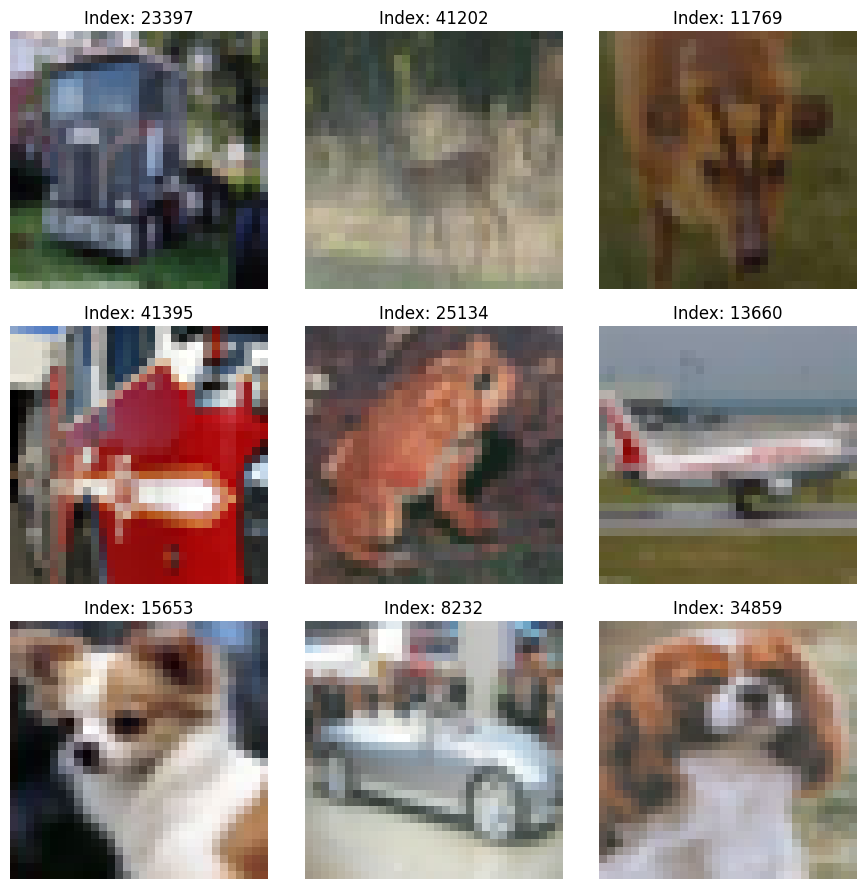

In [4]:
# Task 1

# Display 9 random images (not first or last 9)

# Select 9 random indices, excluding the first and last 9 images
indices = np.random.choice(np.arange(9, len(x_train) - 9), 9, replace=False)

plt.figure(figsize=(9, 9))

for i, index in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[index])
    plt.title(f"Index: {index}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Residual Block

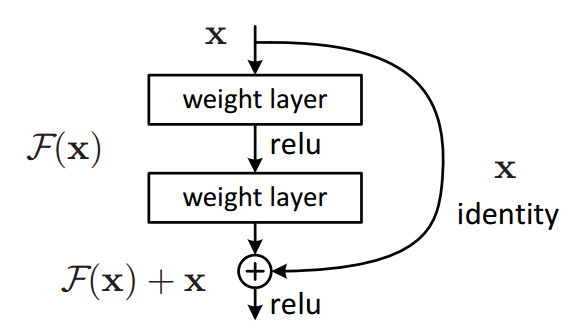


In [5]:
# Implement a residual block

from tensorflow.keras import layers

def residual_block(x, filters, stride=1):

    shortcut = x

    # Main path
    x = layers.Conv2D(filters, 3,
        strides=stride,
        padding="same",
        use_bias=False)(x)

    x = layers.BatchNormalization()(x) #why?

    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3,
        strides=1,
        padding="same",
        use_bias=False)(x)

    x = layers.BatchNormalization()(x)

    # As we have to add x with f(x) --> dimentions must match
    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    # Residual addition
    x = layers.Add()([x, shortcut])

    x = layers.ReLU()(x)

    return x

In [6]:
from tensorflow.keras import Model
from tensorflow.keras import layers


def build_small_resnet(num_classes=10):

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # Initial convolution
    x = layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block group 1
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # Block group 2
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Block group 3
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return Model(inputs, outputs)


model = build_small_resnet()

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 64)   1728        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 32, 32, 64)  256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 32, 32, 64)   0           ['batch_normalization[0][0]']

In [7]:
#compile and train

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

result = model.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
88/88 [==============================] - 234s 3s/step - loss: 1.4572 - accuracy: 0.4789 - val_loss: 3.2470 - val_accuracy: 0.1256
Epoch 2/10
88/88 [==============================] - 244s 3s/step - loss: 0.9295 - accuracy: 0.6700 - val_loss: 3.4019 - val_accuracy: 0.1836
Epoch 3/10
88/88 [==============================] - 243s 3s/step - loss: 0.6963 - accuracy: 0.7532 - val_loss: 2.8375 - val_accuracy: 0.2280
Epoch 4/10
88/88 [==============================] - 242s 3s/step - loss: 0.5480 - accuracy: 0.8069 - val_loss: 1.7895 - val_accuracy: 0.5000
Epoch 5/10
88/88 [==============================] - 242s 3s/step - loss: 0.4414 - accuracy: 0.8470 - val_loss: 1.9037 - val_accuracy: 0.4784
Epoch 6/10
88/88 [==============================] - 243s 3s/step - loss: 0.3403 - accuracy: 0.8834 - val_loss: 2.2600 - val_accuracy: 0.5548
Epoch 7/10
88/88 [==============================] - 242s 3s/step - loss: 0.2594 - accuracy: 0.9118 - val_loss: 1.0086 - val_accuracy: 0.7268
Epoch 8/10
88

# GPU ?

In [8]:
print(
    tf.config.list_physical_devices("GPU")
)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# Evaluate

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.2990058660507202
Test accuracy: 0.6847999691963196


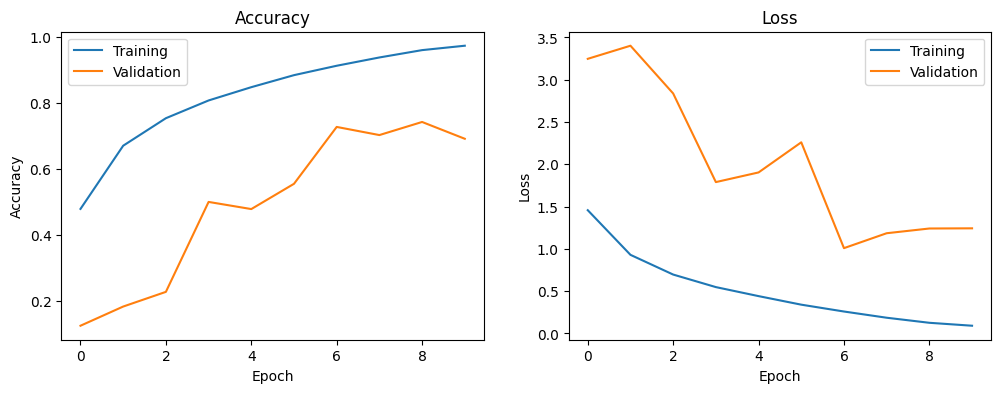

In [10]:
#Training curve

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(result.history["accuracy"])
plt.plot(result.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.subplot(1, 2, 2)
plt.plot(result.history["loss"])
plt.plot(result.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"])

plt.show()

In [11]:
# TODO: Reduce depth

from tensorflow.keras import Model
from tensorflow.keras import layers


def build_small_resnet(num_classes=10):

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # Initial convolution
    x = layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block group 1
    x = residual_block(x, 64)
    x = residual_block(x, 64)



    # Block group 3 (block 2 removed)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return Model(inputs, outputs)


model = build_small_resnet()

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_15 (Conv2D)             (None, 32, 32, 64)   1728        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_15 (BatchN  (None, 32, 32, 64)  256         ['conv2d_15[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 re_lu_13 (ReLU)                (None, 32, 32, 64)   0           ['batch_normalization_15[0]

In [12]:
#compile and train

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

result = model.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
88/88 [==============================] - 347s 4s/step - loss: 1.4453 - accuracy: 0.4763 - val_loss: 3.0590 - val_accuracy: 0.1174
Epoch 2/10
88/88 [==============================] - 345s 4s/step - loss: 1.0078 - accuracy: 0.6443 - val_loss: 3.4793 - val_accuracy: 0.1800
Epoch 3/10
88/88 [==============================] - 351s 4s/step - loss: 0.8240 - accuracy: 0.7097 - val_loss: 2.9661 - val_accuracy: 0.1754
Epoch 4/10
88/88 [==============================] - 344s 4s/step - loss: 0.7060 - accuracy: 0.7534 - val_loss: 2.9407 - val_accuracy: 0.2870
Epoch 5/10
88/88 [==============================] - 345s 4s/step - loss: 0.6019 - accuracy: 0.7929 - val_loss: 2.0458 - val_accuracy: 0.4198
Epoch 6/10
88/88 [==============================] - 344s 4s/step - loss: 0.5231 - accuracy: 0.8184 - val_loss: 1.4574 - val_accuracy: 0.5972
Epoch 7/10
88/88 [==============================] - 344s 4s/step - loss: 0.4679 - accuracy: 0.8394 - val_loss: 0.8599 - val_accuracy: 0.7166
Epoch 8/10
88

In [13]:
# Evaluate

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.8900089263916016
Test accuracy: 0.5686999559402466


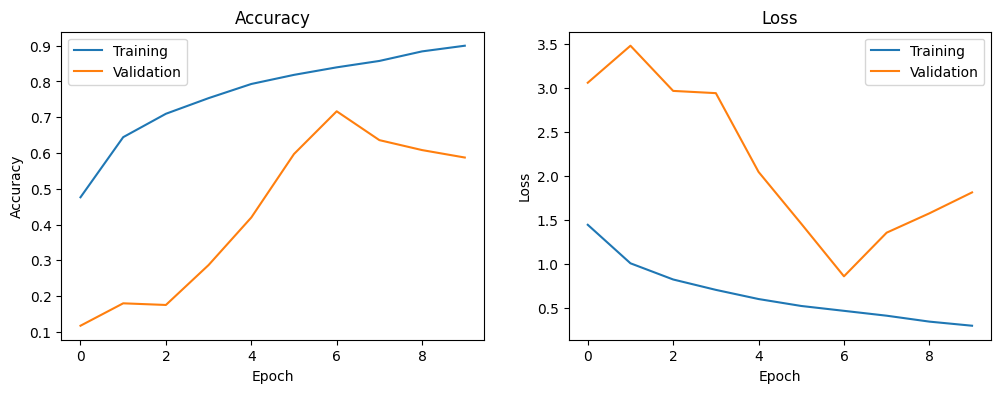

In [14]:
#Training curve

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(result.history["accuracy"])
plt.plot(result.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.subplot(1, 2, 2)
plt.plot(result.history["loss"])
plt.plot(result.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"])

plt.show()

In [15]:
# TODO: Change number of filters as 32 → 64 → 128


from tensorflow.keras import Model
from tensorflow.keras import layers


def build_small_resnet(num_classes=10):

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # Initial convolution
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block group 1
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Block group 2
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    # Block group 3
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return Model(inputs, outputs)


model = build_small_resnet()

model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_25 (Conv2D)             (None, 32, 32, 32)   864         ['input_3[0][0]']                
                                                                                                  
 batch_normalization_25 (BatchN  (None, 32, 32, 32)  128         ['conv2d_25[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 re_lu_22 (ReLU)                (None, 32, 32, 32)   0           ['batch_normalization_25[0]

In [16]:
#compile and train

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

result = model.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
88/88 [==============================] - 76s 845ms/step - loss: 1.4220 - accuracy: 0.4846 - val_loss: 3.1212 - val_accuracy: 0.1416
Epoch 2/10
88/88 [==============================] - 74s 841ms/step - loss: 0.9885 - accuracy: 0.6470 - val_loss: 3.5950 - val_accuracy: 0.1364
Epoch 3/10
88/88 [==============================] - 74s 846ms/step - loss: 0.7839 - accuracy: 0.7238 - val_loss: 2.8745 - val_accuracy: 0.2358
Epoch 4/10
88/88 [==============================] - 74s 843ms/step - loss: 0.6410 - accuracy: 0.7760 - val_loss: 1.3116 - val_accuracy: 0.5496
Epoch 5/10
88/88 [==============================] - 74s 846ms/step - loss: 0.5312 - accuracy: 0.8165 - val_loss: 1.2449 - val_accuracy: 0.5920
Epoch 6/10
88/88 [==============================] - 74s 842ms/step - loss: 0.4437 - accuracy: 0.8481 - val_loss: 0.9521 - val_accuracy: 0.6936
Epoch 7/10
88/88 [==============================] - 74s 841ms/step - loss: 0.3466 - accuracy: 0.8831 - val_loss: 1.3940 - val_accuracy: 0.6266

In [17]:
# Evaluate

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.1441570520401
Test accuracy: 0.6965999603271484


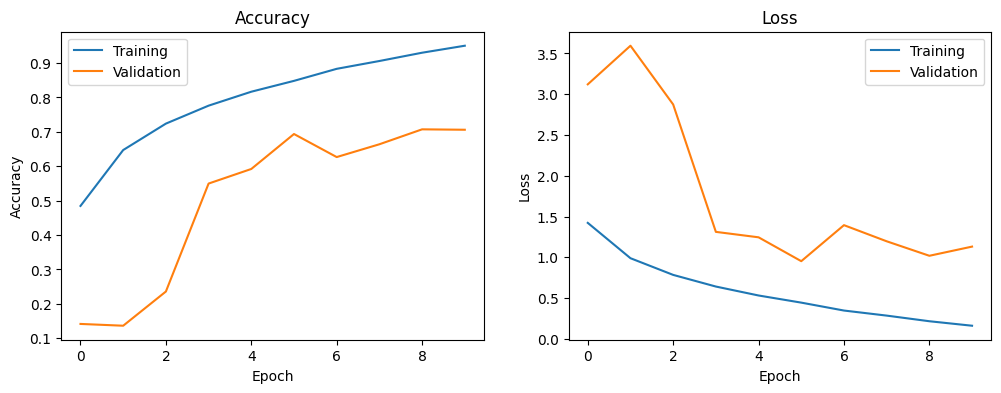

In [18]:
#Training curve

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(result.history["accuracy"])
plt.plot(result.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.subplot(1, 2, 2)
plt.plot(result.history["loss"])
plt.plot(result.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"])

plt.show()

In [19]:
# TODO

# Compare results with LeNet-5 (minor modification to lab 3 and it can be converted to LeNet-5)
# based on training time, accuracy, number of paramters etc...
from tensorflow.keras import Model
from tensorflow.keras import layers
import time

# Build LeNet-5 for CIFAR-10

def build_lenet(num_classes=10):

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # Convolution 1
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # Convolution 2
    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # Convolution 3
    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1
    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    # Fully Connected Layer 2
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    # Classification
    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return Model(inputs, outputs)


lenet_model = build_lenet()

lenet_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_40 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 batch_normalization_40 (Bat  (None, 32, 32, 32)       128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_41 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_41 (Bat  (None, 16, 16, 64)       256 

In [20]:
# Compile and train LeNet

lenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

lenet_result = lenet_model.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

lenet_training_time = time.time() - start_time

Epoch 1/10
88/88 [==============================] - 15s 161ms/step - loss: 1.6233 - accuracy: 0.4373 - val_loss: 3.2323 - val_accuracy: 0.0950
Epoch 2/10
88/88 [==============================] - 14s 160ms/step - loss: 1.1183 - accuracy: 0.6130 - val_loss: 3.7485 - val_accuracy: 0.1480
Epoch 3/10
88/88 [==============================] - 14s 160ms/step - loss: 0.8876 - accuracy: 0.6924 - val_loss: 4.7238 - val_accuracy: 0.1792
Epoch 4/10
88/88 [==============================] - 14s 160ms/step - loss: 0.7252 - accuracy: 0.7489 - val_loss: 4.7557 - val_accuracy: 0.2310
Epoch 5/10
88/88 [==============================] - 14s 162ms/step - loss: 0.5886 - accuracy: 0.7940 - val_loss: 2.6104 - val_accuracy: 0.4296
Epoch 6/10
88/88 [==============================] - 14s 162ms/step - loss: 0.4797 - accuracy: 0.8338 - val_loss: 1.6180 - val_accuracy: 0.5850
Epoch 7/10
88/88 [==============================] - 14s 161ms/step - loss: 0.3832 - accuracy: 0.8689 - val_loss: 1.0839 - val_accuracy: 0.6968

In [21]:
# Evaluate LeNet

lenet_test_loss, lenet_test_accuracy = lenet_model.evaluate(
    x_test,
    y_test,
    verbose=0
)


print("LeNet Test loss:", lenet_test_loss)
print("LeNet Test accuracy:", lenet_test_accuracy)
print("LeNet Training time:", lenet_training_time, "seconds")
print("LeNet Number of parameters:", lenet_model.count_params())


LeNet Test loss: 1.089629054069519
LeNet Test accuracy: 0.7242000102996826
LeNet Training time: 149.32354140281677 seconds
LeNet Number of parameters: 2225738


# Model Comparison Summary

Original ResNet: Test loss: 1.2990 Test accuracy: 68.48%

Reduced Depth ResNet: Test loss: 1.8900 Test accuracy: 56.87%

ResNet with 32 -> 64 -> 128 Filters: Test loss: 1.1442 Test accuracy: 69.66%

LeNet-5: Test loss: 1.0896 Test accuracy: 72.42%

# Accuracy Comparison
Original ResNet: 68.48 % Reduced Depth ResNet: 56.87 % 32 -> 64 -> 128 ResNet: 69.66 % LeNet: 72.42 %

LeNet-5 accuracy improvement over Original ResNet: 3.94 percentage points

# Parameter Comparison
Original ResNet parameters: 2782154 Reduced Depth ResNet parameters: 2091466 32 -> 64 -> 128 ResNet parameters: 698858 LeNet parameters: 2225738
